### Imports
This cell imports the libraries used in the EDA notebook and sets the plotting style.


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams["figure.dpi"] = 120



### Load data
This cell finds the raw CSV files, loads them, and combines them into one dataframe.


In [34]:
candidate_dirs = [
    Path("../../data/raw"),
    Path("distraction_prediction/data/raw"),
]

data_dir = next((p for p in candidate_dirs if p.exists()), None)
if data_dir is None:
    raise FileNotFoundError(
        f"Could not find data directory. Tried: {[str(p) for p in candidate_dirs]}"
    )

files = sorted(data_dir.glob("distract_lstm_features*.csv"))
print(f"Using data dir: {data_dir.resolve()}")
print(f"Found {len(files)} files")

if not files:
    raise FileNotFoundError(
        f"No files matched 'distract_lstm_features*.csv' in {data_dir.resolve()}"
    )

df = pd.concat(
    [pd.read_csv(f, low_memory=False).assign(source_file=f.name) for f in files],
    ignore_index=True,
)

print(f"Combined shape: {df.shape}")
df.head()


Using data dir: E:\SDPPS\distraction_prediction\data\raw
Found 5 files
Combined shape: (65676, 26)


,timestamp,user,foreground_app_start,foreground_app_end,app_switches,final_app_dwell,num_visible_apps,cpu_usage,memory_usage,bytes_sent,...,erase_key_pct,avg_press_interval_ms,std_press_interval_ms,mouse_clicks,mouse_moves,mouse_scrolls,idle_seconds,engagement_momentum,visible_apps,source_file
0,2025-11-16 21:18:32,User,NaN,NaN,0,60,8,14.1,39.6,4352952,...,0.0,0.000000,0.000000,0,571,0,37,571,NVIDIA Overlay.exe;WhatsApp;svchost.exe;WhatsA...,distract_lstm_features -1.csv
1,2025-11-16 21:19:32,User,NaN,brave.exe,2,31,9,16.8,40.0,5687722,...,0.0,212.012053,266.068334,6,1589,0,27,1598,NVIDIA Overlay.exe;WhatsApp;svchost.exe;WhatsA...,distract_lstm_features -1.csv
2,2025-11-16 21:20:32,User,brave.exe,WhatsApp,1,60,10,16.0,39.9,5365281,...,0.0,1352.015376,1894.965293,14,1653,8,20,1672,NVIDIA Overlay.exe;WhatsApp;ApplicationFrameHo...,distract_lstm_features -1.csv
3,2025-11-16 21:21:32,User,WhatsApp,WhatsApp,0,60,9,18.0,40.1,4509394,...,0.0,2681.167024,6001.261674,28,2413,0,4,2449,NVIDIA Overlay.exe;WhatsApp;ApplicationFrameHo...,distract_lstm_features -1.csv
4,2025-11-16 21:22:33,User,WhatsApp,brave.exe,3,19,11,13.1,40.3,1841009,...,0.0,1072.028041,1266.718980,35,3525,38,3,3563,NVIDIA Overlay.exe;WhatsApp;EXCEL.EXE;Applicat...,distract_lstm_features -1.csv


### Basic cleaning
This cell parses timestamps, sorts the records, and converts the main features to numeric format.


In [35]:
# Parse timestamps and clean basic types
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

invalid_ts = df["timestamp"].isna().sum()
print(f"Rows with invalid timestamp: {invalid_ts}")

df = df.dropna(subset=["timestamp"]).copy()
df = df.sort_values(["user", "timestamp"]).reset_index(drop=True)

numeric_cols = [
    "app_switches", "final_app_dwell", "num_visible_apps",
    "cpu_usage", "memory_usage", "bytes_sent", "bytes_received",
    "hour", "session_time_minutes", "keystroke_count",
    "erase_key_count", "erase_key_pct", "avg_press_interval_ms",
    "std_press_interval_ms", "mouse_clicks", "mouse_moves",
    "mouse_scrolls", "idle_seconds", "engagement_momentum",
]

df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

print(f"Clean shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head(3)


Rows with invalid timestamp: 2518
Clean shape: 63,158 rows x 26 columns


,timestamp,user,foreground_app_start,foreground_app_end,app_switches,final_app_dwell,num_visible_apps,cpu_usage,memory_usage,bytes_sent,...,erase_key_pct,avg_press_interval_ms,std_press_interval_ms,mouse_clicks,mouse_moves,mouse_scrolls,idle_seconds,engagement_momentum,visible_apps,source_file
0,2025-11-13 21:16:23,Hasrith,NaN,WhatsApp,1,60,5,15.0,50.1,121402,...,0.0,0.000000,0.000000,8,1486,0,20,1494,WhatsApp;Settings;SystemSettings.exe;Grammarly...,distract_lstm_features -4.csv
1,2025-11-13 21:17:23,Hasrith,WhatsApp,WhatsApp,0,60,5,9.2,50.0,70733,...,0.0,265.725692,1615.056400,6,812,0,28,870,WhatsApp;Settings;SystemSettings.exe;Grammarly...,distract_lstm_features -4.csv
2,2025-11-13 21:18:23,Hasrith,WhatsApp,WhatsApp,4,38,6,16.3,50.4,394140,...,0.0,501.457956,1240.083859,5,1494,0,24,1518,WhatsApp;Settings;EXCEL.EXE;Grammarly.Desktop....,distract_lstm_features -4.csv


### Dataset overview
This cell shows the size, column types, and first few rows of the dataset.


In [36]:
# Dataset overview
print("Dataset overview")
print(f"Total records: {len(df):,}")
print(f"Unique users: {df['user'].nunique()}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"Source files: {df['source_file'].nunique()}")
print(f"Users found: {df['user'].dropna().unique().tolist()}")
print(f"Number of columns: {df.shape[1]}")
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")


Dataset overview
Total records: 63,158
Unique users: 2
Date range: 2025-11-13 21:16:23 to 2026-01-26 21:21:52
Source files: 4
Users found: ['Hasrith', 'User']
Number of columns: 26
1. timestamp
2. user
3. foreground_app_start
4. foreground_app_end
5. app_switches
6. final_app_dwell
7. num_visible_apps
8. cpu_usage
9. memory_usage
10. bytes_sent
11. bytes_received
12. hour
13. day_of_week
14. session_time_minutes
15. keystroke_count
16. erase_key_count
17. erase_key_pct
18. avg_press_interval_ms
19. std_press_interval_ms
20. mouse_clicks
21. mouse_moves
22. mouse_scrolls
23. idle_seconds
24. engagement_momentum
25. visible_apps
26. source_file


### Missing values
This cell checks how many values are missing in each numeric feature.


In [45]:
df[numeric_cols].isna().sum()


app_switches                0
final_app_dwell             0
num_visible_apps            0
cpu_usage                   0
memory_usage                0
bytes_sent                  0
bytes_received              0
hour                        0
session_time_minutes        0
keystroke_count             0
erase_key_count             0
erase_key_pct               0
avg_press_interval_ms       0
std_press_interval_ms    1503
mouse_clicks                0
mouse_moves                 0
mouse_scrolls               0
idle_seconds                0
engagement_momentum         0
dtype: int64

### Descriptive statistics
This cell summarizes the main numeric features using count, mean, standard deviation, and quartiles.


In [38]:
# Descriptive statistics
df[numeric_cols].describe().round(2)


,app_switches,final_app_dwell,num_visible_apps,cpu_usage,memory_usage,bytes_sent,bytes_received,hour,session_time_minutes,keystroke_count,erase_key_count,erase_key_pct,avg_press_interval_ms,std_press_interval_ms,mouse_clicks,mouse_moves,mouse_scrolls,idle_seconds,engagement_momentum
count,63158.00,63158.00,63158.00,63158.00,63158.00,6.315800e+04,6.315800e+04,63158.00,63158.00,63158.00,63158.0,63158.00,63158.00,61655.00,63158.00,63158.00,63158.00,63158.00,63158.00
mean,0.71,100.33,9.34,14.02,53.61,1.156189e+06,1.350732e+07,13.26,655.34,88.33,1.5,3.08,627.34,990.99,5.95,679.25,26.26,36.47,773.53
std,1.70,1325.96,3.03,8.96,12.32,4.725172e+06,8.298466e+07,6.27,809.26,300.59,8.1,11.41,2455.78,2506.49,11.18,966.15,107.51,23.50,1037.93
min,0.00,2.00,2.00,0.00,25.80,0.000000e+00,0.000000e+00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,60.00,7.00,7.80,44.70,5.703300e+04,6.649100e+04,9.00,97.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,12.00,0.00
50%,0.00,60.00,9.00,11.10,50.00,1.770790e+05,3.680910e+05,13.00,318.00,0.00,0.0,0.00,0.00,0.00,1.00,150.00,0.00,43.00,279.00
75%,0.00,60.00,11.00,17.90,62.10,5.967995e+05,3.116072e+06,19.00,862.00,34.00,0.0,0.00,412.27,787.80,8.00,1113.00,5.00,60.00,1298.00
max,39.00,159758.00,19.00,90.60,97.10,2.985213e+08,7.144014e+09,23.00,4954.00,3640.00,601.0,100.00,55768.39,41277.41,246.00,5619.00,2530.00,62.00,5952.00


### Class balance
This cell loads the labeled dataset and shows the distribution of focused and distracted samples.


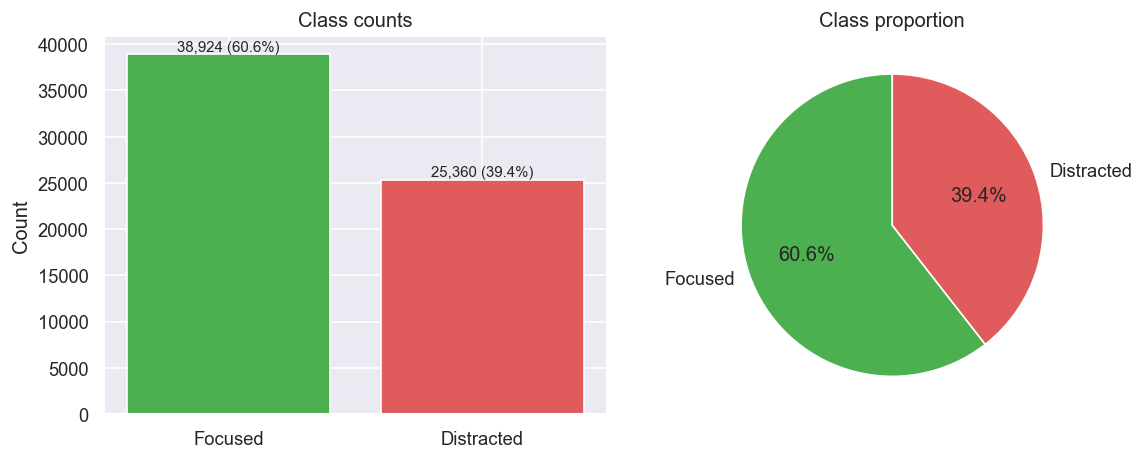

Imbalance ratio: 1.53:1


In [39]:
# Class balance
labeled_candidates = [
    Path("../../data/processed/windows/labeled_activity_log.csv"),
    Path("distraction_prediction/data/processed/windows/labeled_activity_log.csv"),
]

labeled_csv = next((p for p in labeled_candidates if p.exists()), None)
if labeled_csv is None:
    raise FileNotFoundError(f"Could not find labeled_activity_log.csv. Tried: {[str(p) for p in labeled_candidates]}")

df_lbl = pd.read_csv(labeled_csv)
vc = df_lbl["distraction_label"].value_counts().sort_index()
label_names = {0: "Focused", 1: "Distracted"}

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar([label_names.get(i, str(i)) for i in vc.index], vc.values, color=["#4CAF50", "#E05C5C"], edgecolor="white")
for i, v in enumerate(vc.values):
    axes[0].text(i, v, f"{v:,} ({v / len(df_lbl) * 100:.1f}%)", ha="center", va="bottom", fontsize=9)
axes[0].set_title("Class counts")
axes[0].set_ylabel("Count")

axes[1].pie(vc.values, labels=[label_names.get(i, str(i)) for i in vc.index], autopct="%1.1f%%", colors=["#4CAF50", "#E05C5C"], startangle=90, wedgeprops={"edgecolor": "white"})
axes[1].set_title("Class proportion")

plt.tight_layout()
plt.show()

print(f"Imbalance ratio: {vc.max() / vc.min():.2f}:1")


### Feature distributions
This cell plots the distribution of each numeric feature and marks the median value.


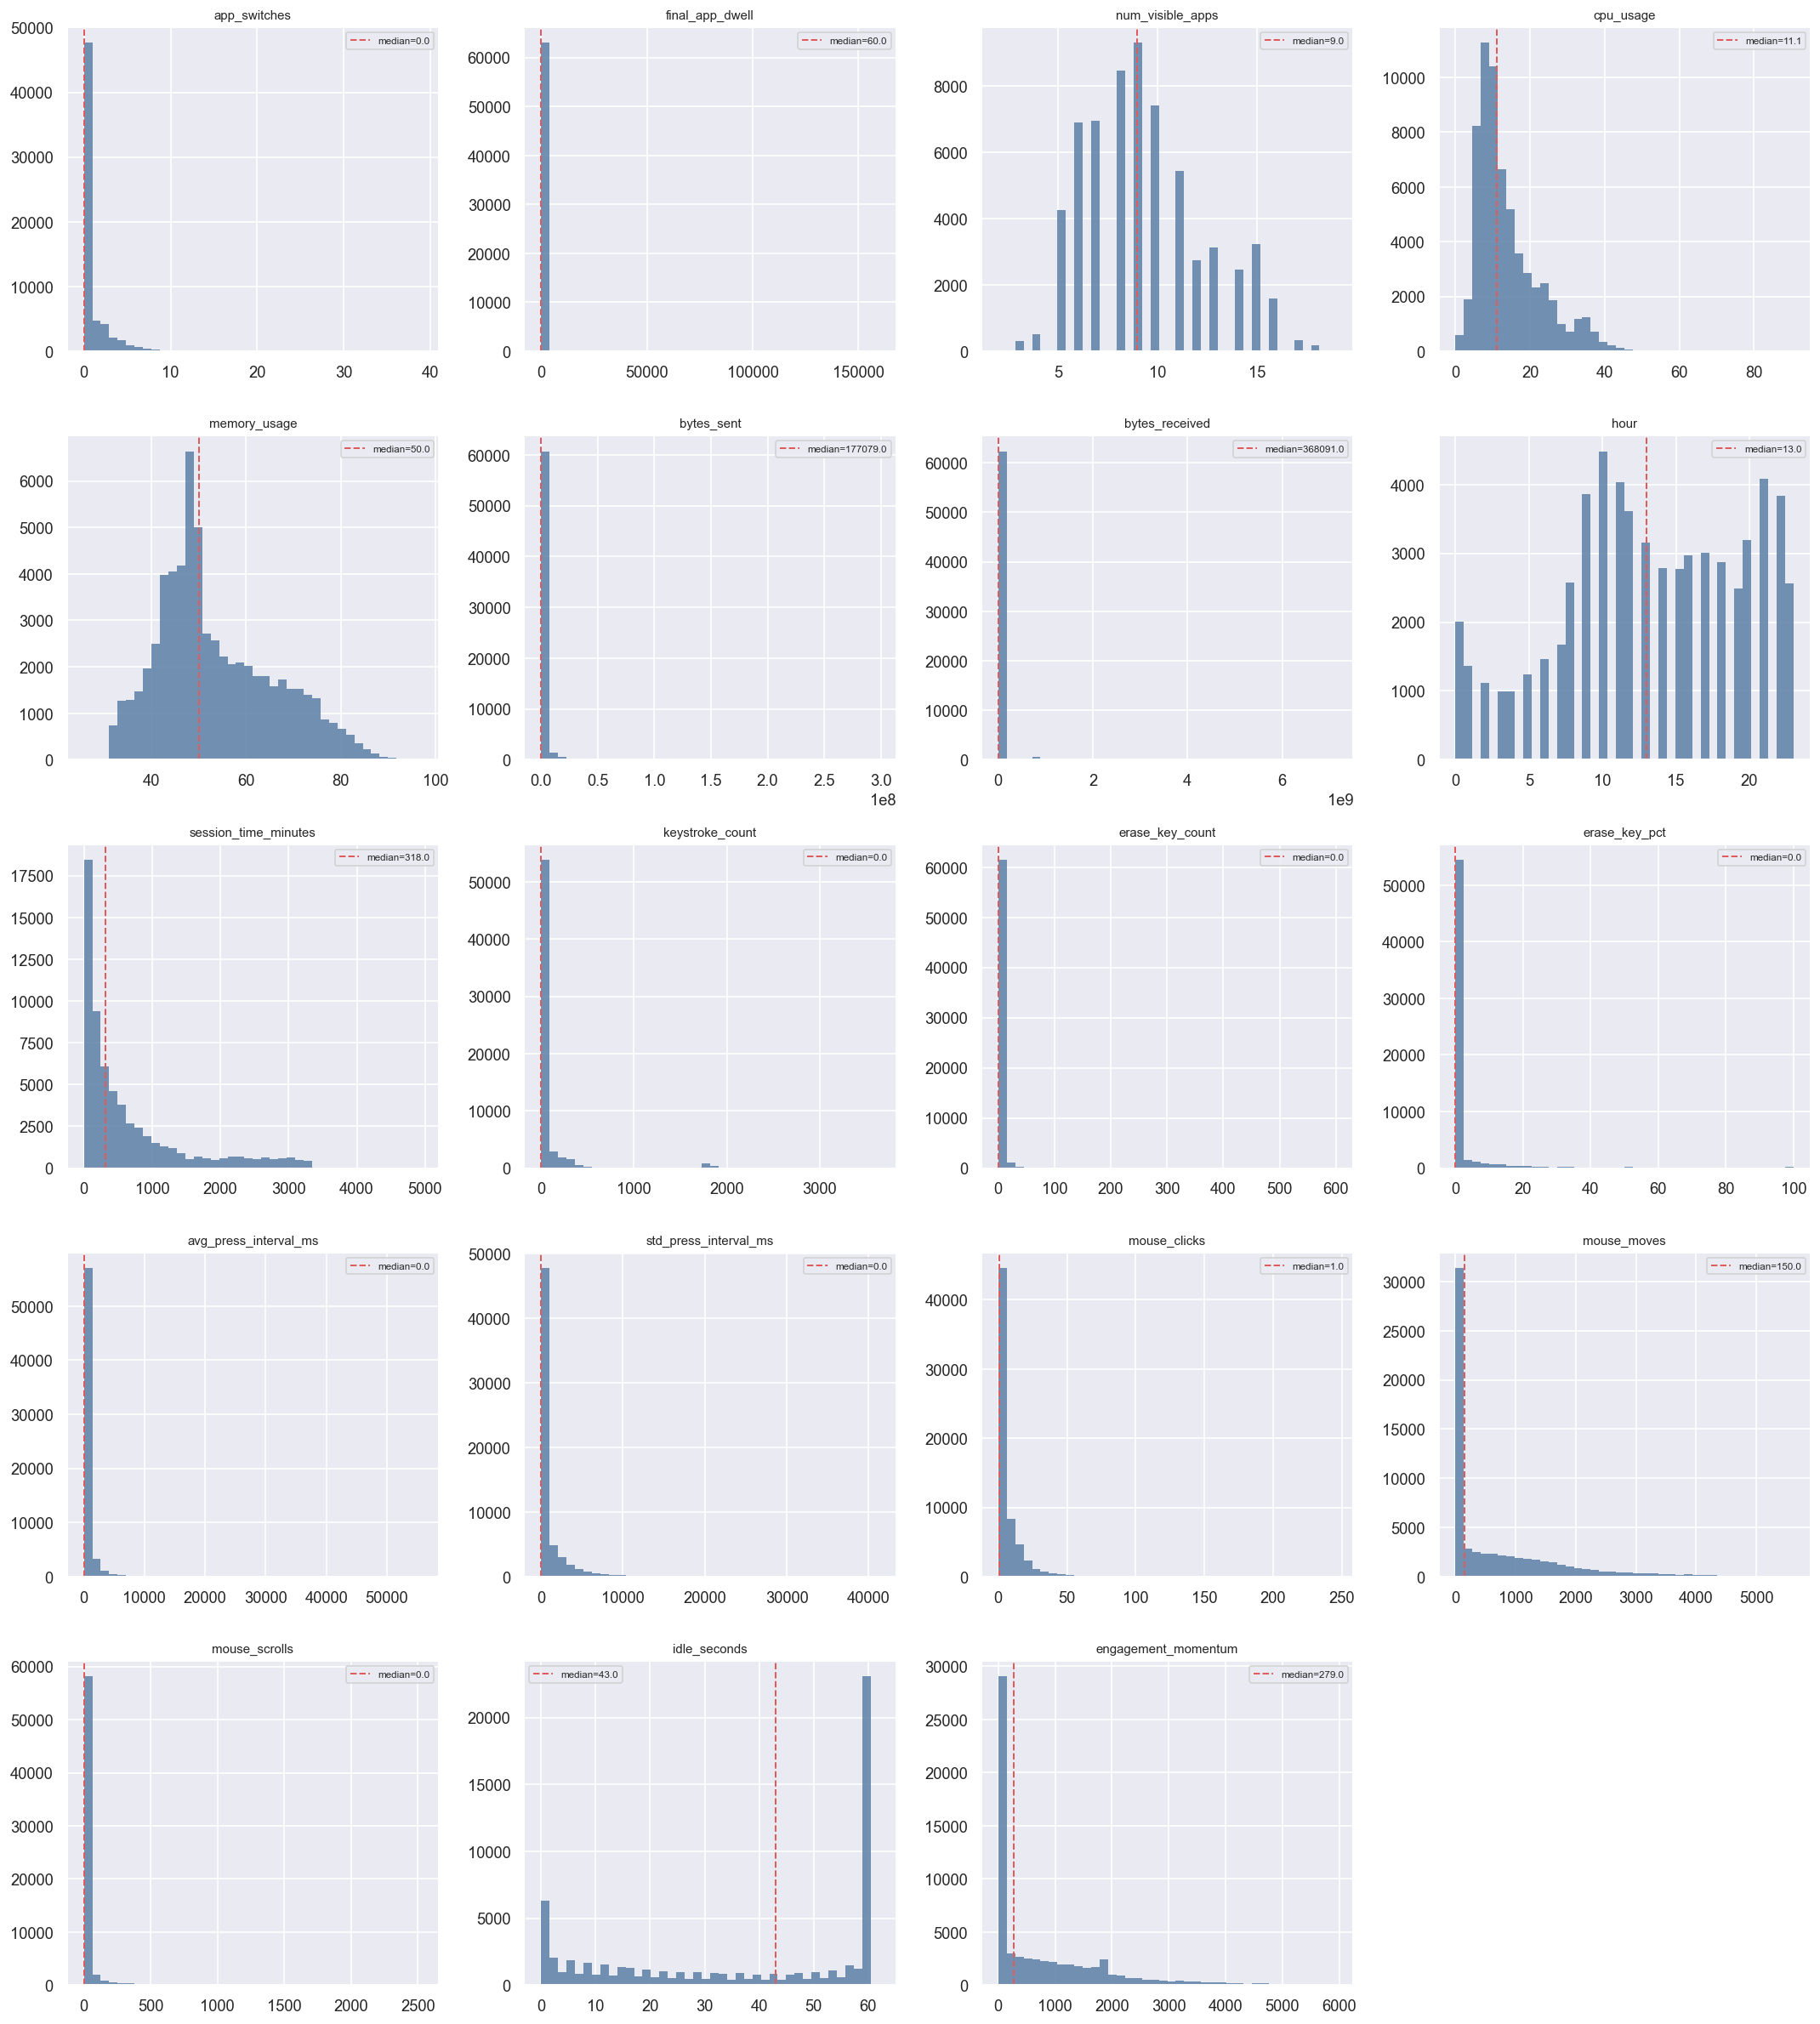

In [40]:
# Feature distributions
n_cols = 4
n_rows = int(np.ceil(len(numeric_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = np.array(axes).flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=40, color="#5B7FA6", edgecolor="none", alpha=0.85)
    axes[i].axvline(df[col].median(), color="#E05C5C", linestyle="--", linewidth=1.2, label=f"median={df[col].median():.1f}")
    axes[i].set_title(col, fontsize=9)
    axes[i].legend(fontsize=7)

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


### Correlation heatmap
This cell shows the linear relationship between numeric features.


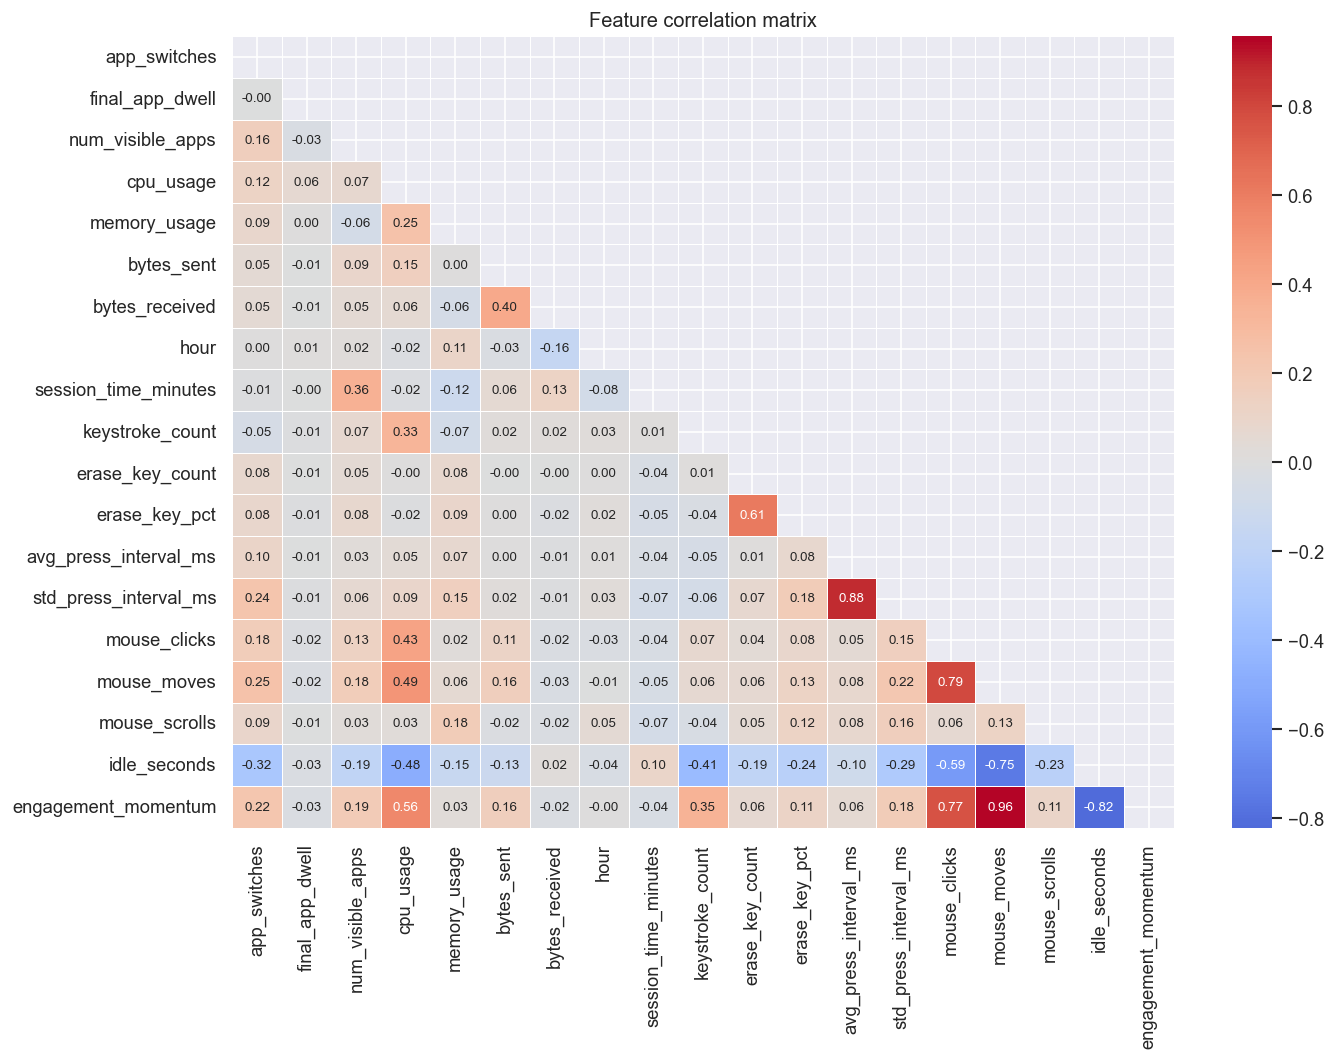

In [41]:
# Correlation heatmap
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.4, annot_kws={"size": 8})
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.show()


### Feature distribution by label
This cell compares important features between focused and distracted samples.


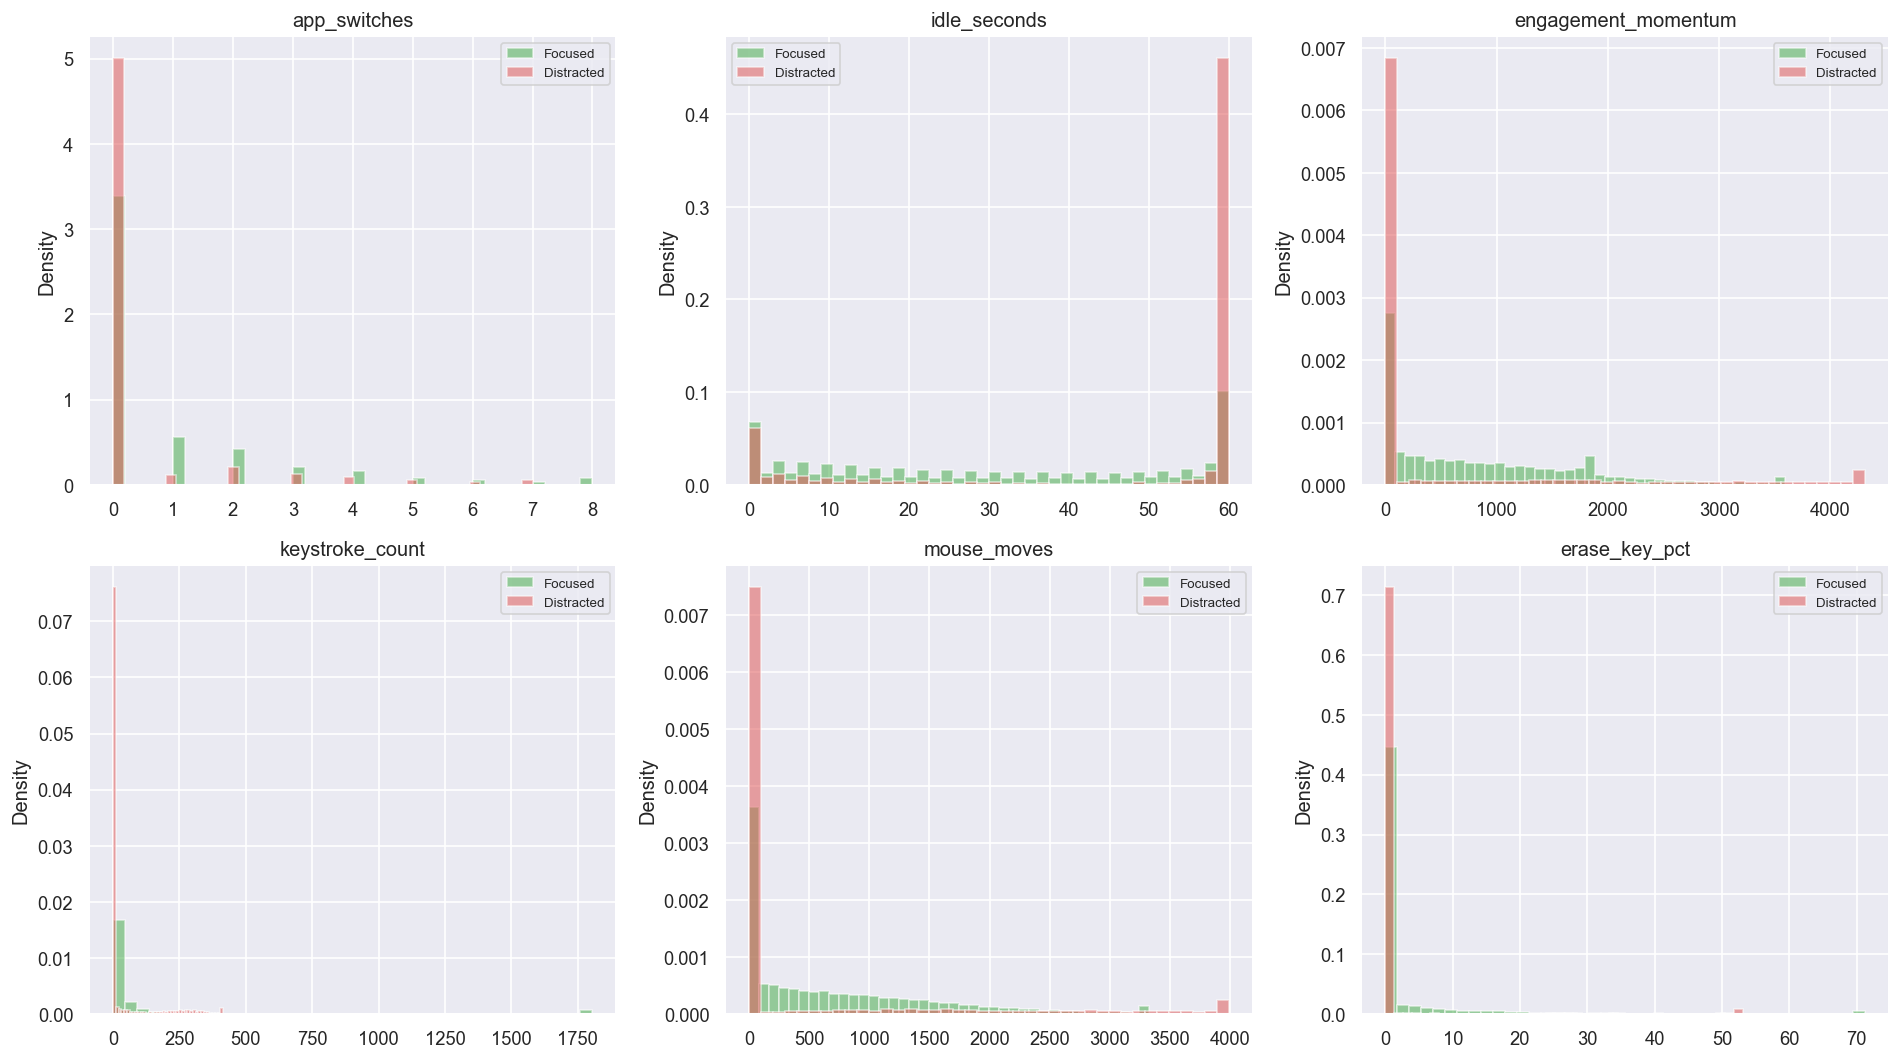

In [42]:
# Feature distribution by label
key_feats = ["app_switches", "idle_seconds", "engagement_momentum", "keystroke_count", "mouse_moves", "erase_key_pct"]
key_feats = [feat for feat in key_feats if feat in df_lbl.columns]
colors = {0: "#4CAF50", 1: "#E05C5C"}
label_names = {0: "Focused", 1: "Distracted"}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, feat in enumerate(key_feats):
    for lbl in sorted(df_lbl["distraction_label"].dropna().unique()):
        data = df_lbl.loc[df_lbl["distraction_label"] == lbl, feat].dropna()
        if not data.empty:
            data = data.clip(upper=data.quantile(0.99))
            axes[i].hist(data, bins=40, alpha=0.55, density=True, color=colors.get(lbl, "gray"), label=label_names.get(lbl, str(lbl)))
    axes[i].set_title(feat)
    axes[i].set_ylabel("Density")
    axes[i].legend(fontsize=8)

for j in range(len(key_feats), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


### Engagement momentum over time
This cell shows how engagement momentum changes over time for each user.


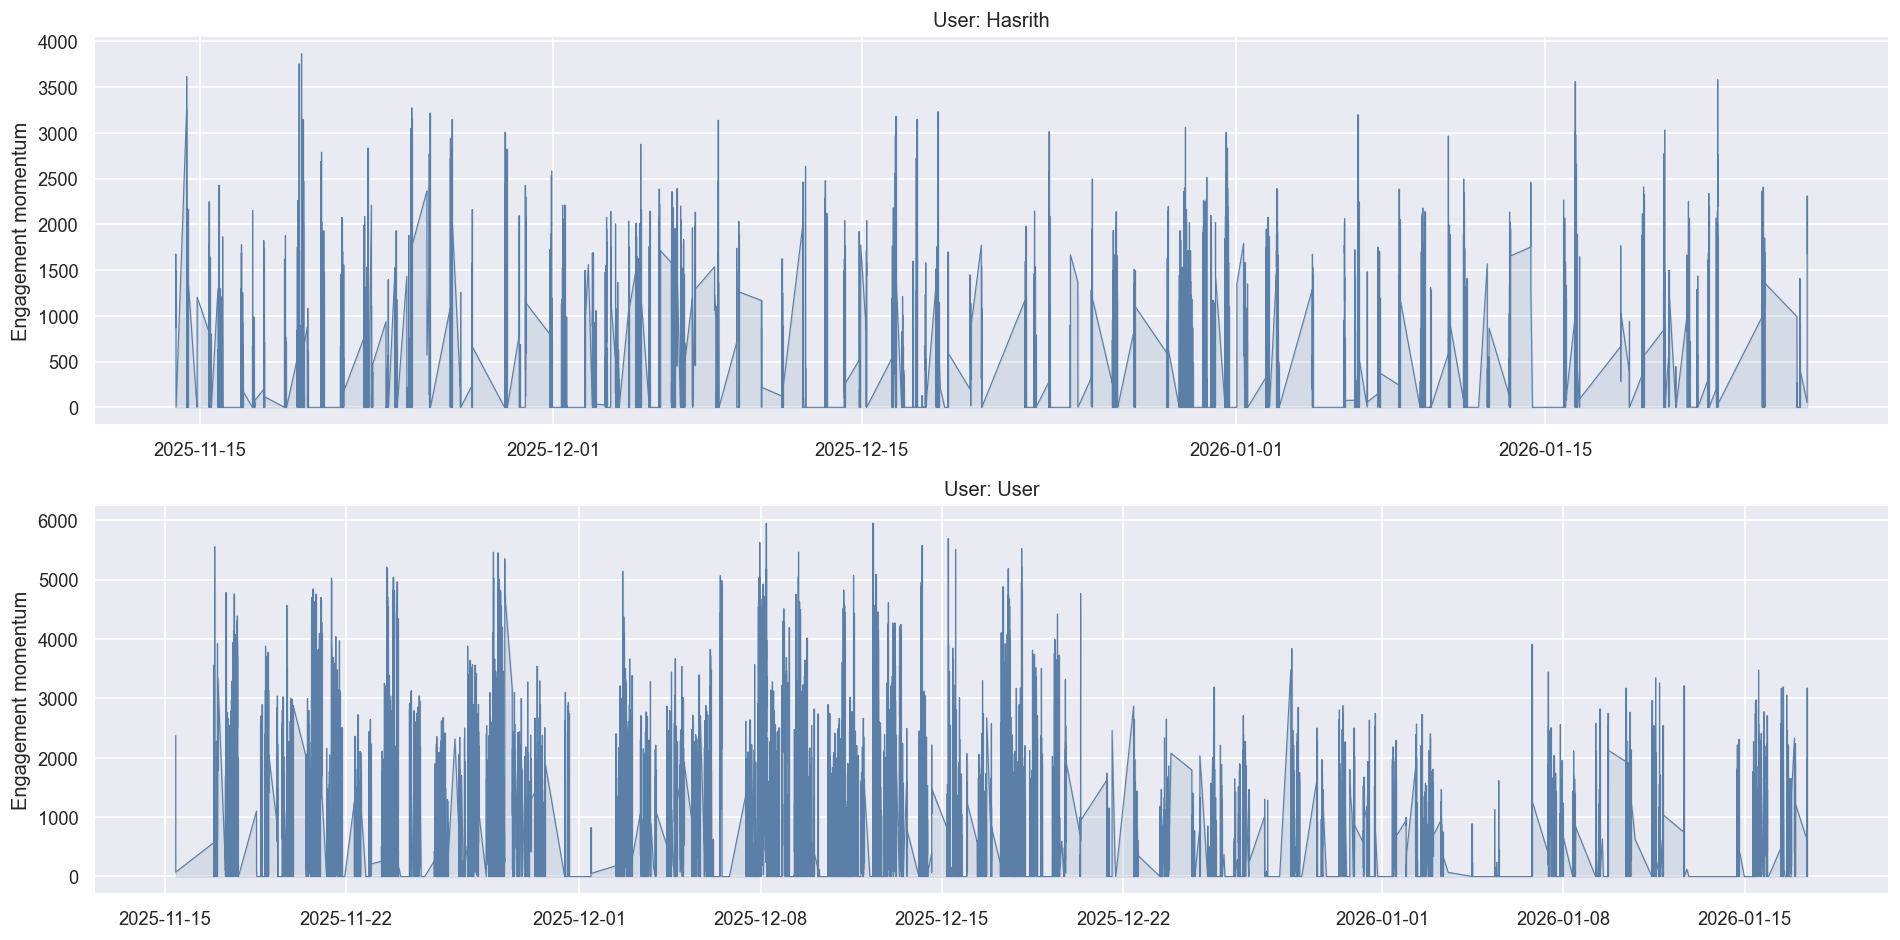

In [43]:
# Engagement momentum over time
n_users = df["user"].nunique()
fig, axes = plt.subplots(n_users, 1, figsize=(16, 4 * n_users), sharex=False)

if n_users == 1:
    axes = [axes]

for ax, (user, grp) in zip(axes, df.groupby("user")):
    grp = grp.sort_values("timestamp")
    ax.plot(grp["timestamp"], grp["engagement_momentum"], linewidth=0.7, color="#5B7FA6")
    ax.fill_between(grp["timestamp"], grp["engagement_momentum"], alpha=0.15, color="#5B7FA6")
    ax.set_title(f"User: {user}")
    ax.set_ylabel("Engagement momentum")

plt.tight_layout()
plt.show()


### Distraction rate by app category
This cell shows how distraction rate changes across app categories, if that column is available.


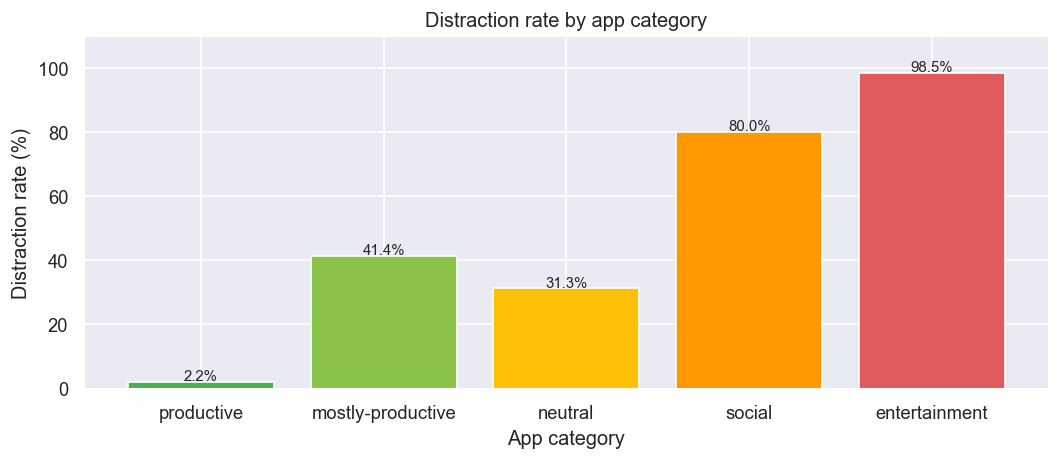

In [44]:
# Distraction rate by app category
if "app_category" in df_lbl.columns:
    cat_order = ["productive", "mostly-productive", "neutral", "social", "entertainment"]

    cat_stats = (
        df_lbl.groupby("app_category")["distraction_label"]
        .mean()
        .mul(100)
        .reindex(cat_order)
        .dropna()
        .reset_index()
        .rename(columns={"distraction_label": "distraction_rate_pct"})
    )

    plt.figure(figsize=(9, 4))
    bars = plt.bar(cat_stats["app_category"], cat_stats["distraction_rate_pct"], color=["#4CAF50", "#8BC34A", "#FFC107", "#FF9800", "#E05C5C"][: len(cat_stats)], edgecolor="white")
    for bar, val in zip(bars, cat_stats["distraction_rate_pct"]):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5, f"{val:.1f}%", ha="center", fontsize=9)
    plt.title("Distraction rate by app category")
    plt.ylabel("Distraction rate (%)")
    plt.xlabel("App category")
    plt.ylim(0, 110)
    plt.tight_layout()
    plt.show()
else:
    print("Column app_category is not available in the labeled dataset")
